In [1]:
import os
import random
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image

import matplotlib.pyplot as plt

import torch

plt.rcParams["figure.figsize"] = (6, 6)

In [2]:
DATA_ROOT = Path("/kaggle/input/beyond-visible-spectrum-ai-for-agriculture-2026")
DATASET_DIR = DATA_ROOT / "Kaggle_Prepared"

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR   = DATASET_DIR / "val"

RGB_DIR = "RGB"
MS_DIR  = "MS"
HS_DIR  = "HS"

In [3]:
# reproducibility package
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# DataFrame 

## for train

In [9]:
def build_train_df(train_dir: Path) -> pd.DataFrame:
    """function for constructing a DataFrame based on train data"""
    rows = []

    rgb_path = train_dir / RGB_DIR

    # Iterating through all files in the RGB folder
    # os.listdir(rgb_path) returns file names, not paths
    for fname in sorted(os.listdir(rgb_path)):
        if not fname.endswith(".png"):
            continue

        sample_id = fname.replace(".png", "")
        category = sample_id.split("_")[0]  # Health / Rust / Other

        rows.append({
            "Id": sample_id,
            "Category": category,
            "rgb_path": train_dir / RGB_DIR / f"{sample_id}.png",
            "ms_path":  train_dir / MS_DIR  / f"{sample_id}.tif",
            "hs_path":  train_dir / HS_DIR  / f"{sample_id}.tif",
        })

    return pd.DataFrame(rows)

train_df = build_train_df(TRAIN_DIR)
train_df.head()

,Id,Category,rgb_path,ms_path,hs_path
0,Health_hyper_1,Health,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
1,Health_hyper_10,Health,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
2,Health_hyper_100,Health,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
3,Health_hyper_101,Health,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
4,Health_hyper_102,Health,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...


In [5]:
print("Train samples:", len(train_df))
train_df["Category"].value_counts()

Train samples: 600


Category
Rust      200
Other     200
Health    200
Name: count, dtype: int64

In [6]:
def check_files_exist(df: pd.DataFrame):
    for col in ["rgb_path", "ms_path", "hs_path"]:
        missing = ~df[col].apply(lambda x: Path(x).exists())
        print(f"{col}: missing files =", missing.sum())

check_files_exist(train_df)

rgb_path: missing files = 0
ms_path: missing files = 0
hs_path: missing files = 0


## for validation

In [8]:
def build_val_df(val_dir: Path) -> pd.DataFrame:
    """function for constructing a DataFrame based on validation data"""
    rows = []

    rgb_path = val_dir / RGB_DIR

    # Iterating through all files in the RGB folder
    # os.listdir(rgb_path) returns file names, not paths
    for fname in sorted(os.listdir(rgb_path)):
        if not fname.endswith(".png"):
            continue

        sample_id = fname.replace(".png", "")

        rows.append({
            "Id": sample_id,
            "Category": np.nan,    # target
            "rgb_path": val_dir / RGB_DIR / f"{sample_id}.png",
            "ms_path":  val_dir / MS_DIR  / f"{sample_id}.tif",
            "hs_path":  val_dir / HS_DIR  / f"{sample_id}.tif",
        })

    return pd.DataFrame(rows)

val_df = build_val_df(VAL_DIR)
val_df.head()

,Id,Category,rgb_path,ms_path,hs_path
0,val_000a83c1,NaN,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
1,val_00a704b1,NaN,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
2,val_01dde030,NaN,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
3,val_024df365,NaN,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
4,val_02afcb0e,NaN,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...


In [8]:
check_files_exist(val_df)

rgb_path: missing files = 0
ms_path: missing files = 0
hs_path: missing files = 0


# Visualization

In [9]:
sample = train_df.sample(1).iloc[0]
sample

Id                                              Rust_hyper_62
Category                                                 Rust
rgb_path    /kaggle/input/beyond-visible-spectrum-ai-for-a...
ms_path     /kaggle/input/beyond-visible-spectrum-ai-for-a...
hs_path     /kaggle/input/beyond-visible-spectrum-ai-for-a...
Name: 110, dtype: object

In [10]:
img_rgb = Image.open(sample["rgb_path"])
print("RGB size:", img_rgb.size)

RGB size: (64, 64)


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

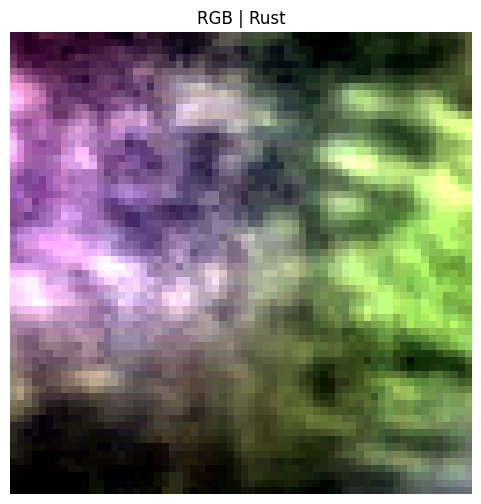

In [11]:
plt.imshow(img_rgb)
plt.title(f"RGB | {sample['Category']}")
plt.axis("off")

In [12]:
try:
    import rasterio
except ModuleNotFoundError:
    !pip install rasterio
    import rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 38.9 MB/s eta 0:00:00:00:0100:01


In [13]:
import warnings
from rasterio.errors import NotGeoreferencedWarning

warnings.filterwarnings(
    "ignore",
    category=NotGeoreferencedWarning
)

In [14]:
with rasterio.open(sample["ms_path"]) as src:
    ms = src.read()
    print("MS shape:", ms.shape)  # (C, H, W)

MS shape: (5, 64, 64)


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

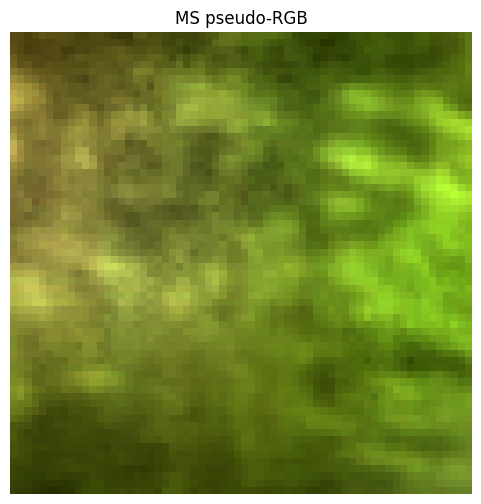

In [15]:
# MS: B, G, R = 0,1,2
ms_rgb = np.stack([
    ms[2],  # R
    ms[1],  # G
    ms[0],  # B
], axis=-1)

ms_rgb = (ms_rgb - ms_rgb.min()) / (ms_rgb.max() - ms_rgb.min())

plt.imshow(ms_rgb)
plt.title("MS pseudo-RGB")
plt.axis("off")

In [16]:
with rasterio.open(sample["hs_path"]) as src:
    hs = src.read()
    print("HS shape:", hs.shape)  # (C, H, W)

HS shape: (125, 32, 32)


(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

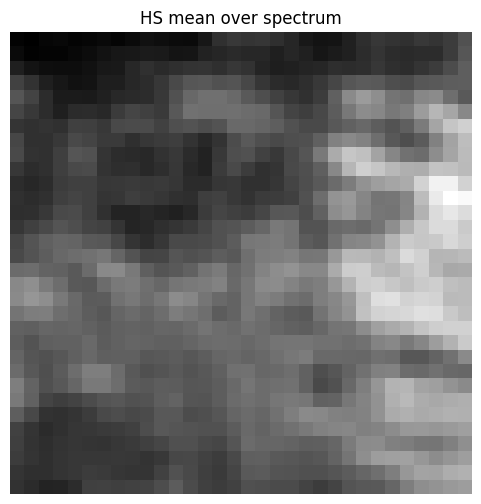

In [17]:
hs_mean = hs.mean(axis=0)

plt.imshow(hs_mean, cmap="gray")
plt.title("HS mean over spectrum")
plt.axis("off")

In [18]:
def find_constant_triplets(
    df: pd.DataFrame,
    eps: float = 1e-6,
    show: int = 30,
    check_cols=("rgb_path", "ms_path", "hs_path"),
) -> pd.DataFrame:
    """
    One-pass check for constant (all-zero / constant) images across multiple modalities.
    Returns a single DataFrame with stats per modality and flags.
    Also prints intersection sizes incl. All three.
    """

    def _read_stats(path) -> tuple[float, float, float]:
        with rasterio.open(path) as src:
            x = src.read().astype(np.float32)
        return float(x.min()), float(x.max()), float(np.std(x))

    rows = []
    for idx, row in df.iterrows():
        rec = {"index": idx, "Id": row["Id"], "Category": row.get("Category", np.nan)}

        # compute stats per modality
        flags = []
        for col in check_cols:
            mn, mx, sd = _read_stats(row[col])
            rec[f"{col}_min"] = mn
            rec[f"{col}_max"] = mx
            rec[f"{col}_std"] = sd
            is_const = (sd < eps)
            rec[f"{col}_const"] = bool(is_const)
            flags.append(is_const)

        # aggregate flags
        rec["any_const"] = bool(np.any(flags))
        rec["all_three_const"] = bool(np.all(flags))

        if rec["any_const"]:
            rows.append(rec)

    out = pd.DataFrame(rows)

    # summary sets
    def _ids_where(col_flag: str) -> set:
        if out.empty:
            return set()
        return set(out.loc[out[col_flag], "Id"].tolist())

    rgb_ids = _ids_where("rgb_path_const")
    ms_ids  = _ids_where("ms_path_const")
    hs_ids  = _ids_where("hs_path_const")

    print("RGB ∩ MS:", len(rgb_ids & ms_ids))
    print("RGB ∩ HS:", len(rgb_ids & hs_ids))
    print("MS  ∩ HS:", len(ms_ids & hs_ids))
    print("All three:", len(rgb_ids & ms_ids & hs_ids))

    # show only all-three (since that's what you care about)
    if not out.empty:
        all_three_df = out[out["all_three_const"]].copy()

        print("\nAll-three constant samples:", len(all_three_df))
        if len(all_three_df) > 0:
            # compact view
            cols_view = ["index", "Id", "Category",
                         "rgb_path_min","rgb_path_max","rgb_path_std",
                         "ms_path_min","ms_path_max","ms_path_std",
                         "hs_path_min","hs_path_max","hs_path_std"]
            display(all_three_df[cols_view].head(show))

            print("\nCategory counts (all three):")
            display(all_three_df["Category"].value_counts(dropna=False))

        return all_three_df

    return out  # empty

In [19]:
bad_df = find_constant_triplets(train_df, eps=1e-6, show=50)

RGB ∩ MS: 23
RGB ∩ HS: 23
MS  ∩ HS: 23
All three: 23

All-three constant samples: 23


,index,Id,Category,rgb_path_min,rgb_path_max,rgb_path_std,ms_path_min,ms_path_max,ms_path_std,hs_path_min,hs_path_max,hs_path_std
0,32,Other_hyper_26,Other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,76,Other_hyper_64,Other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,121,Other_hyper_113,Other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,123,Other_hyper_163,Other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,144,Other_hyper_174,Other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,175,Health_hyper_34,Health,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,224,Health_hyper_167,Health,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,240,Health_hyper_38,Health,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,242,Other_hyper_50,Other,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,266,Health_hyper_67,Health,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Category counts (all three):


Category
Other     14
Health     9
Name: count, dtype: int64

In [20]:
bad_val_df = find_constant_triplets(val_df, eps=1e-6, show=50)

RGB ∩ MS: 11
RGB ∩ HS: 11
MS  ∩ HS: 11
All three: 11

All-three constant samples: 11


,index,Id,Category,rgb_path_min,rgb_path_max,rgb_path_std,ms_path_min,ms_path_max,ms_path_std,hs_path_min,hs_path_max,hs_path_std
0,9,val_5adcdc2e,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,46,val_6b6509fd,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,59,val_ceaa5449,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,63,val_5a361ff8,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,132,val_6cef0158,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,159,val_8e35e5d5,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,165,val_147643a2,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,201,val_d768878f,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,214,val_05cee914,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,246,val_f1a4afff,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Category counts (all three):


Category
NaN    11
Name: count, dtype: int64

In [21]:
from collections import defaultdict

def check_channels(df, col_path):
    has_category = "Category" in df.columns and df["Category"].notna().any()

    if has_category:
        stats = defaultdict(set)

        for _, row in df.iterrows():
            with rasterio.open(row[col_path]) as src:
                c = src.count
            stats[row["Category"]].add(c)

        for cat, chans in stats.items():
            print(f"{col_path} | {cat}: channels = {chans}")

    else:
        chans = set()
        for _, row in df.iterrows():
            with rasterio.open(row[col_path]) as src:
                chans.add(src.count)

        print(f"{col_path} | ALL: channels = {chans}")

In [22]:
check_channels(train_df, "rgb_path")
check_channels(train_df, "ms_path")
check_channels(train_df, "hs_path")

rgb_path | Rust: channels = {3}
rgb_path | Other: channels = {3}
rgb_path | Health: channels = {3}
ms_path | Rust: channels = {5}
ms_path | Other: channels = {5}
ms_path | Health: channels = {5}
hs_path | Rust: channels = {125, 126}
hs_path | Other: channels = {125, 126}
hs_path | Health: channels = {125, 126}


In [23]:
check_channels(val_df, "rgb_path")
check_channels(val_df, "ms_path")
check_channels(val_df, "hs_path")

rgb_path | ALL: channels = {3}
ms_path | ALL: channels = {5}
hs_path | ALL: channels = {125, 126}


**Dataset Summary & Key Findings**

Dataset Overview
- Training set: **600 samples**
- Classes: **3** (`Health`, `Rust`, `Other`)
- Class distribution: **balanced** (200 samples per class)
- Validation set: provided **without labels**
- Missing files: **none** (all modalities are available for all samples)

---

**Data Modalities & Spatial Resolution**
- **RGB**: `(3, 64, 64)`
- **Multispectral (MS)**: `(5, 64, 64)`
- **Hyperspectral (HS)**: `(125 or 126, 32, 32)`

RGB and MS share the same spatial resolution, while HS has a **lower spatial resolution** and a variable number of channels.

---

**Constant (All-Zero) Samples**
- Training set: **23 samples**
  - Categories: `Other` (14), `Health` (9), `Rust` (0)
- Validation set: **11 samples**
- For these samples:
  - **All three modalities are fully constant**
  - Pixel values are exactly `0.0`
- This is a known dataset artifact and must be handled explicitly during training and inference.

---

**Channel Consistency**
- RGB: always **3 channels**
- MS: always **5 channels**
- HS: **125 or 126 channels** across all classes (not class-dependent)

Therefore, HS requires **explicit channel unification** (e.g. cropping to a fixed number of spectral bands) before modeling.

---

**Practical Implications**
- The dataset is **clean, balanced, and small** → no class weighting is required.
- RGB provides a limited disease signal at this spatial resolution.
- HS contains rich spectral information but:
  - has lower spatial resolution,
  - high dimensionality,
  - a variable channel count,
  - and requires additional preprocessing.

---

**Baseline Strategy**

**Multispectral (MS)** is the most suitable modality to start with:
- includes **Red Edge and NIR** bands strongly linked to plant health,
- preserves full spatial resolution (64×64),
- has a fixed and compact channel count,
- offers the best signal-to-complexity trade-off for an initial baseline.## Dataset Summary & Key Findings

**Dataset Overview**
- Training set: **600 samples**
- Classes: **3** (`Health`, `Rust`, `Other`)
- Class distribution: **balanced** (200 samples per class)
- Validation set: provided **without labels**
- Missing files: **none** (all modalities are available for all samples)

---

**Data Modalities & Spatial Resolution**
- **RGB**: `(3, 64, 64)`
- **Multispectral (MS)**: `(5, 64, 64)`
- **Hyperspectral (HS)**: `(125 or 126, 32, 32)`

RGB and MS share the same spatial resolution, while HS has a **lower spatial resolution** and a variable number of channels.

---

**Constant (All-Zero) Samples**
- Training set: **23 samples**
  - Categories: `Other` (14), `Health` (9), `Rust` (0)
- Validation set: **11 samples**
- For these samples:
  - **All three modalities are fully constant**
  - Pixel values are exactly `0.0`
- This is a known dataset artifact and must be handled explicitly during training and inference.

---

**Channel Consistency**
- RGB: always **3 channels**
- MS: always **5 channels**
- HS: **125 or 126 channels** across all classes (not class-dependent)

Therefore, HS requires **explicit channel unification** (e.g. cropping to a fixed number of spectral bands) before modeling.

---

**Practical Implications**
- The dataset is **clean, balanced, and small** → no class weighting is required.
- RGB provides a limited disease signal at this spatial resolution.
- HS contains rich spectral information but:
  - has lower spatial resolution,
  - high dimensionality,
  - a variable channel count,
  - and requires additional preprocessing.

---

**Baseline Strategy**

**Multispectral (MS)** is the most suitable modality to start with:
- includes **Red Edge and NIR** bands strongly linked to plant health,
- preserves full spatial resolution (64×64),
- has a fixed and compact channel count,
- offers the best signal-to-complexity trade-off for an initial baseline.

In [10]:
train_df.to_csv('train_df.csv', index=False)
val_df.to_csv('val_df.csv', index=False)